In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

#scan files in the current directory
data_dir = os.getcwd()
files = [f for f in os.listdir(data_dir) if f.endswith('.npz')]

dataset='emc'

In [27]:
#load the files that start with 'tuh_ss' and end with 'star.npz'
data_list = []
for f in files:
    if f.startswith(f'{dataset}_ss')  and  not f.endswith('star.npz'):
        data = np.load(os.path.join(data_dir, f))
        data_list.append((f, data))

for filename, data in data_list:
    print(f"Processing file: {filename}")
    # Example: print the keys in the npz file
    print(f"Keys in the npz file {filename}: {data.files}")
data_list_ensembles = []
for f in files:
    if f.startswith(f'{dataset}_ens')  and not f.endswith('star.npz'):
        data = np.load(os.path.join(data_dir, f))
        data_list_ensembles.append((f, data))
for filename, data in data_list_ensembles:
    print(f"Processing ensemble file: {filename}")
    # Example: print the keys in the npz file
    print(f"Keys in the npz file {filename}: {data.files}")

#merge the two data lists
data_list.extend(data_list_ensembles)
data_list.sort()
for i, (filename, data) in enumerate(data_list):
    print(f"{i}: {filename}")


Processing file: emc_ss_hv.npz
Keys in the npz file emc_ss_hv.npz: ['fpr', 'tpr']
Processing file: emc_ss_ips.npz
Keys in the npz file emc_ss_ips.npz: ['fpr', 'tpr']
Processing file: emc_ss_bg.npz
Keys in the npz file emc_ss_bg.npz: ['fpr', 'tpr']
Processing ensemble file: emc_ens_bg.npz
Keys in the npz file emc_ens_bg.npz: ['fpr', 'tpr', 'auc']
Processing ensemble file: emc_ens_hv-nr.npz
Keys in the npz file emc_ens_hv-nr.npz: ['fpr', 'tpr', 'auc']
Processing ensemble file: emc_ens_ips.npz
Keys in the npz file emc_ens_ips.npz: ['fpr', 'tpr', 'auc']
Processing ensemble file: emc_ens_hv-r.npz
Keys in the npz file emc_ens_hv-r.npz: ['fpr', 'tpr', 'auc']
Processing ensemble file: emc_ens_hv.npz
Keys in the npz file emc_ens_hv.npz: ['fpr', 'tpr', 'auc']
0: emc_ens_bg.npz
1: emc_ens_hv-nr.npz
2: emc_ens_hv-r.npz
3: emc_ens_hv.npz
4: emc_ens_ips.npz
5: emc_ss_bg.npz
6: emc_ss_hv.npz
7: emc_ss_ips.npz


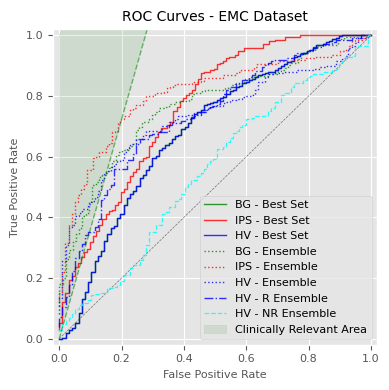

In [28]:
plt.style.use('ggplot')
# Available data paths

# 0: emc_ens_bg.npz
# 1: emc_ens_hv-nr.npz
# 2: emc_ens_hv-r.npz
# 3: emc_ens_hv.npz
# 4: emc_ens_ips.npz
# 5: emc_ss_bg.npz
# 6: emc_ss_hv.npz
# 7: emc_ss_ips.npz

slope = 3.6153846153846154

plt.figure(figsize=(4,4))
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=0.5)

data_bg=data_list[6][1]
fpr_bg = data_bg['fpr']
tpr_bg = data_bg['tpr']
plt.step(fpr_bg, tpr_bg, label='BG - Best Set', alpha=0.8, color='green', linewidth=1)

data_ips=data_list[7][1]
fpr_ips = data_ips['fpr']   
tpr_ips = data_ips['tpr']
plt.step(fpr_ips, tpr_ips, label='IPS - Best Set', alpha=0.8, color='red', linewidth=1)

data_hv=data_list[6][1]
fpr_hv = data_hv['fpr']   
tpr_hv = data_hv['tpr']
plt.step(fpr_hv, tpr_hv, label='HV - Best Set', alpha=0.8, color='blue' , linewidth=1)

data_bg_ens=data_list[0][1]
fpr_bg_ens = data_bg_ens['fpr']
tpr_bg_ens = data_bg_ens['tpr']
plt.step(fpr_bg_ens, tpr_bg_ens, label='BG - Ensemble', alpha=0.8, color='green', linestyle='dotted', linewidth=1)

data_ips_ens=data_list[4][1]
fpr_ips_ens = data_ips_ens['fpr']   
tpr_ips_ens = data_ips_ens['tpr']
plt.step(fpr_ips_ens, tpr_ips_ens, label='IPS - Ensemble', alpha=0.8, color='red', linestyle='dotted', linewidth=1)  

data_hv_ens=data_list[3][1]
fpr_hv_ens = data_hv_ens['fpr']   
tpr_hv_ens = data_hv_ens['tpr']
plt.step(fpr_hv_ens, tpr_hv_ens, label='HV - Ensemble', alpha=0.8, color='blue', linestyle='dotted', linewidth=1)

data_hv_r_ens=data_list[2][1]
fpr_hv_r_ens = data_hv_r_ens['fpr']   
tpr_hv_r_ens = data_hv_r_ens['tpr']
plt.step(fpr_hv_r_ens, tpr_hv_r_ens, label='HV - R Ensemble', alpha=0.8, color='blue', linestyle='-.', linewidth=1)

data_hv_nr_ens=data_list[1][1]
fpr_hv_nr_ens = data_hv_nr_ens['fpr']   
tpr_hv_nr_ens = data_hv_nr_ens['tpr']
plt.step(fpr_hv_nr_ens, tpr_hv_nr_ens, label='HV - NR Ensemble', alpha=0.8, color='cyan', linestyle='dashed', linewidth=0.9)




plt.xlabel('False Positive Rate', fontsize=10)
plt.ylabel('True Positive Rate', fontsize=10)


plt.plot([0, 1], [0, slope], '--', color='green', alpha=0.5, linewidth=1) #fill above the line
plt.fill_between([0, 1], [0, slope],[1, slope], color='green', alpha=0.1, label='Clinically Relevant Area')

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.legend(loc='lower right', fontsize=8)
plt.xlabel('False Positive Rate', fontsize=8)
plt.ylabel('True Positive Rate', fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.title('ROC Curves - EMC Dataset', fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.savefig(f'roc_{dataset}.pdf', dpi=300)
plt.show()
